<a href="https://colab.research.google.com/github/mayur07699/MLDS/blob/main/IQR2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('/IPLPlayerStat-1.csv')

In [3]:
df.head(10)

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0
5,5,A Dananjaya,4,0,5,0.0,25.0,47.0,1,4.00,80.00,0.00,11.28,470000.00,250000.00,0.0,0.0
6,6,A Flintoff,62,7,57,2.0,66.0,106.0,3,20.67,108.77,12.28,9.64,53.00,33.00,3.0,0.0
7,7,A Kumble,35,3,49,45.0,983.0,1089.0,42,0.83,71.43,6.12,6.65,24.20,21.84,9.0,0.0
8,8,A Manohar,108,17,79,0.0,0.0,0.0,7,15.43,136.71,21.52,0.00,0.00,0.00,4.0,0.0
9,9,A Mishra,362,34,410,166.0,3317.0,4022.0,154,2.35,88.29,8.29,7.28,24.23,19.98,18.0,0.0


In [4]:
df.shape

(605, 17)

In [5]:
num_col = df.select_dtypes(include='number').columns

In [6]:
print(num_col)

Index(['Unnamed: 0', 'runs', 'boundaries', 'balls_faced', 'wickets',
       'balls_bowled', 'runs_conceded', 'matches', 'batting_avg',
       'batting_strike_rate', 'boundaries_percent', 'bowling_economy',
       'bowling_avg', 'bowling_strike_rate', 'catches', 'stumpings'],
      dtype='object')


In [8]:
df[['batting_strike_rate']].describe()

,batting_strike_rate
count,605.000000
mean,100.663719
std,39.956245
min,0.000000
25%,78.750000
50%,107.270000
75%,125.000000
max,400.000000


In [10]:
df[['batting_strike_rate']].isnull().sum()

,0
batting_strike_rate,0


In [11]:
import matplotlib.pyplot as plt

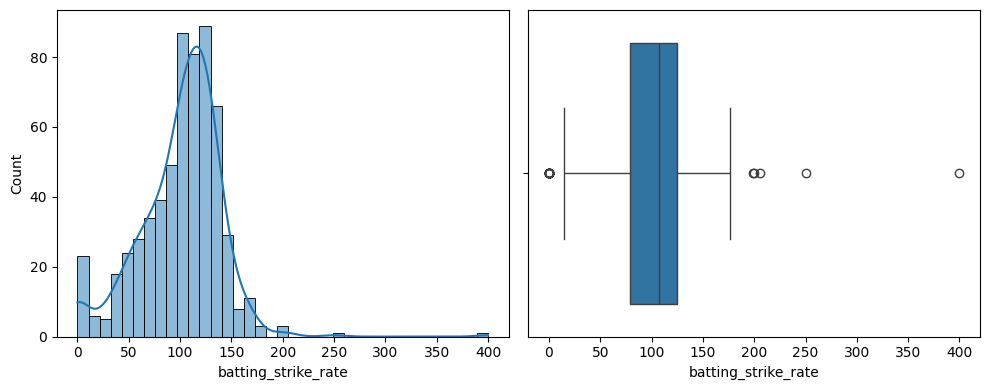

In [15]:
plt.figure(figsize =(10,4))

plt.subplot(1,2,1)
sns.histplot(df['batting_strike_rate'],kde=True)

plt.subplot(1,2,2)
sns.boxplot(x=df['batting_strike_rate'])

plt.tight_layout()
plt.show()

In [53]:
df1 = df.copy()
Q1 = df1['bowling_strike_rate'].quantile(0.25)
Q3 = df1['bowling_strike_rate'].quantile(0.75)
median = df1['bowling_strike_rate'].quantile(0.5)
iqr = Q3-Q1
lower = Q1 - 1.5*iqr
upper = Q3 + 1.5*iqr
print('Q1',Q1)
print('Q2',Q2)
print('iqr',iqr)
print('Median',median)
print('lower',lower)
print('upper',upper)


Q1 0.0
Q2 28.0
iqr 28.0
Median 20.86
lower -42.0
upper 70.0


In [55]:
df1.shape

(605, 17)

In [58]:
outlier = df[(df['bowling_strike_rate']< lower) |
(df['bowling_strike_rate']> upper)]

In [59]:
print(len(outlier))

0


In [34]:
df.columns

Index(['Unnamed: 0', 'player', 'runs', 'boundaries', 'balls_faced', 'wickets',
       'balls_bowled', 'runs_conceded', 'matches', 'batting_avg',
       'batting_strike_rate', 'boundaries_percent', 'bowling_economy',
       'bowling_avg', 'bowling_strike_rate', 'catches', 'stumpings'],
      dtype='object')

In [36]:
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [50]:
out=[ 'runs', 'boundaries', 'balls_faced', 'wickets',
       'balls_bowled', 'runs_conceded', 'matches', 'batting_avg',
       'batting_strike_rate', 'boundaries_percent', 'bowling_economy',
       'bowling_avg', 'bowling_strike_rate', 'catches', 'stumpings']
for col in out:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1

  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR

  outlier=df[(df[col]<lower_limit) |(df[col]>upper_limit)]

  print(f"{col}:{len(outlier)} outlier")

  df[col]=df[col].clip(lower=lower_limit,upper=upper_limit)


runs:0 outlier
boundaries:0 outlier
balls_faced:0 outlier
wickets:0 outlier
balls_bowled:0 outlier
runs_conceded:0 outlier
matches:0 outlier
batting_avg:0 outlier
batting_strike_rate:0 outlier
boundaries_percent:0 outlier
bowling_economy:0 outlier
bowling_avg:0 outlier
bowling_strike_rate:0 outlier
catches:0 outlier
stumpings:0 outlier


<Axes: xlabel='runs'>

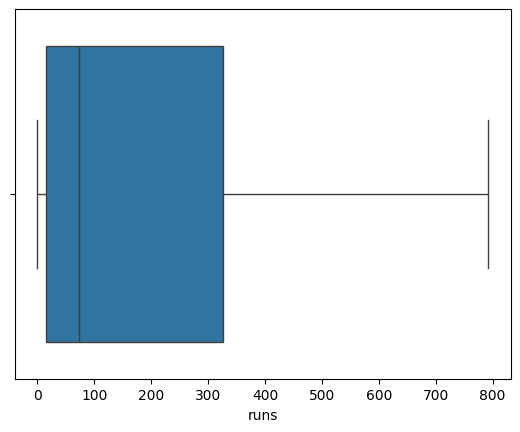

In [46]:
sns.boxplot(data=df,x='runs')

In [60]:
data = pd.read_csv('/IPLPlayerStat-1.csv')

In [61]:
data.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [63]:
col = data.select_dtypes(include='number')

In [91]:
for out in col:
  Q1 = data[out].quantile(0.25)
  Q3 = data[out].quantile(0.75)
  Q2 = data[out].quantile(0.5)
  iqr = Q3-Q1
  lower = Q1 - 1.5*iqr
  upper = Q3 + 1.5*iqr
  outlier = data[(data[out]<lower) | (data[out]>upper)]
  print(f"{out}:{len(outlier)},outlier")


Unnamed: 0:0,outlier
runs:0,outlier
boundaries:0,outlier
balls_faced:0,outlier
wickets:0,outlier
balls_bowled:0,outlier
runs_conceded:0,outlier
matches:0,outlier
batting_avg:0,outlier
batting_strike_rate:0,outlier
boundaries_percent:0,outlier
bowling_economy:0,outlier
bowling_avg:0,outlier
bowling_strike_rate:0,outlier
catches:0,outlier
stumpings:0,outlier


In [85]:
trim_df = pd.read_csv('/IPLPlayerStat-1.csv')

In [86]:
df


,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280.0,31,196.0,18.0,270.0,400.0,28.0,10.00,142.860,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161.0,18,139.0,2.0,12.0,12.0,11.0,14.64,115.830,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4.0,0,7.0,11.0,234.0,245.0,12.0,0.33,57.140,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53.0,7,75.0,0.0,0.0,0.0,6.0,8.83,70.670,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25.0,2,20.0,5.0,108.0,144.0,5.0,5.00,125.000,10.00,8.00,28.80,21.60,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,600,Yash Dayal,0.0,0,1.0,11.0,205.0,296.0,9.0,0.00,9.375,0.00,8.66,26.91,18.64,1.0,0.0
601,601,Yashpal Singh,47.0,5,67.0,0.0,0.0,0.0,4.0,11.75,70.150,7.46,0.00,0.00,0.00,3.0,0.0
602,602,Younis Khan,3.0,0,7.0,0.0,0.0,0.0,1.0,3.00,42.860,0.00,0.00,0.00,0.00,1.0,0.0
603,603,Yuvraj Singh,792.5,96,685.5,36.0,882.0,1091.0,98.5,21.35,124.780,16.63,7.42,30.31,24.50,29.0,0.0


In [87]:
 = df.copy()
Q1 = df1['bowling_strike_rate'].quantile(0.25)
Q3 = df1['bowling_strike_rate'].quantile(0.75)
median = df1['bowling_strike_rate'].quantile(0.5)
iqr = Q3-Q1
lower = Q1 - 1.5*iqr
upper = Q3 + 1.5*iqr
print('Q1',Q1)
print('Q2',Q2)
print('iqr',iqr)
print('Median',median)
print('lower',lower)
print('upper',upper)

Q1 0.0
Q2 0.0
iqr 28.0
Median 20.86
lower -42.0
upper 70.0
